In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
##Modelling
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [3]:
df=pd.read_csv('data/stud.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [39]:
##dependent and independent variable
X=df.drop(columns=['math_score'],axis=1)
y=df['math_score']

In [9]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [40]:
num_features=X.select_dtypes(exclude="object").columns
cat_features=X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer

num_transformer=StandardScaler()
cat_transformer=OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ("onehotencoder",cat_transformer,cat_features),
        ("standardscaler",num_transformer,num_features),
    ]


)
X=preprocessor.fit_transform(X)




In [42]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape , X_test.shape

((800, 19), (200, 19))

In [44]:
##create an evaluate function to give all metrics fter model training
def evaluate(true,predicted):
    mae=mean_absolute_error(true,predicted)
    mse=mean_squared_error(true,predicted)
    rmse=np.sqrt(mse)
    r2_square=r2_score(true,predicted)
    return mae,rmse,r2_square

In [52]:
models={
    "linear regression":LinearRegression(),
    "lasso":Lasso(),
    "ridge":Ridge(),
    "K-Neighbors regressor": KNeighborsRegressor(),
    "Decision Tree":DecisionTreeRegressor(),
    "random forest regressor":RandomForestRegressor(),
    "XGBRegressor":XGBRegressor(),
    "CatBoosting regressor": CatBoostRegressor(verbose=False),
    "adaboost regressor": AdaBoostRegressor()

}

model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)    ##train model

    ##make predictions
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    ##evaluate train and test dataset
    model_train_mae,model_train_rmse,model_train_r2=evaluate(y_train,y_train_pred)
    model_test_mae,model_test_rmse,model_test_r2=evaluate(y_test,y_test_pred)



    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("model performance for training set")
    print("mae: {:.4f}".format(model_train_mae))
    print("rmse: {:.4f}".format(model_train_rmse))
    print("r2_score: {:.4f}".format(model_train_r2))

    print("------------------------------------")


    print("model performance for testing set")
    print("mae: {:.4f}".format(model_test_mae))
    print("rmse: {:.4f}".format(model_test_rmse))
    print("r2_score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    print("**********************************")


linear regression
model performance for training set
mae: 4.2787
rmse: 5.3273
r2_score: 0.8741
------------------------------------
model performance for testing set
mae: 4.2259
rmse: 5.4096
r2_score: 0.8797
**********************************
lasso
model performance for training set
mae: 5.2063
rmse: 6.5938
r2_score: 0.8071
------------------------------------
model performance for testing set
mae: 5.1579
rmse: 6.5197
r2_score: 0.8253
**********************************
ridge
model performance for training set
mae: 4.2650
rmse: 5.3233
r2_score: 0.8743
------------------------------------
model performance for testing set
mae: 4.2111
rmse: 5.3904
r2_score: 0.8806
**********************************
K-Neighbors regressor
model performance for training set
mae: 4.5187
rmse: 5.7122
r2_score: 0.8553
------------------------------------
model performance for testing set
mae: 5.6160
rmse: 7.2516
r2_score: 0.7839
**********************************
Decision Tree
model performance for training set

In [53]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model_name',"R2_score"])

,Model_name,R2_score
0,linear regression,0.879740
1,lasso,0.825320
2,ridge,0.880593
3,K-Neighbors regressor,0.783898
4,Decision Tree,0.741779
5,random forest regressor,0.849590
6,XGBRegressor,0.827797
7,CatBoosting regressor,0.851632
8,adaboost regressor,0.850255


In [60]:
linear=LinearRegression()
linear.fit(X_train,y_train)
y_pred=linear.predict(X_test)
score=r2_score(y_test,y_pred)*100
print("accuracy of the model is %.2f" %score)

accuracy of the model is 87.97


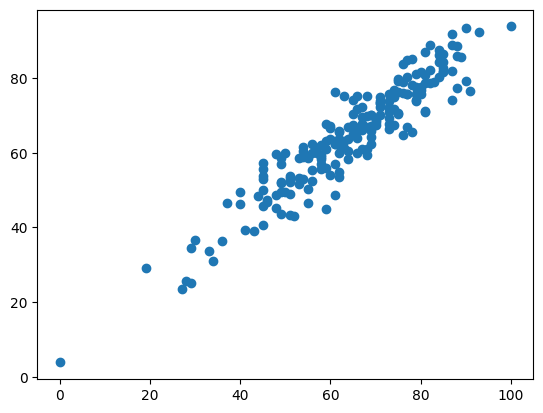

In [61]:
plt.scatter(y_test,y_pred)